# Logistic Regression — Kaggle: Breast Cancer Wisconsin

**Dataset:** [Breast Cancer Wisconsin (Diagnostic)](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)  
**Task:** Binary classification — predict **Malignant (M)** vs **Benign (B)** from cell nucleus measurements.

**Download first:**
```bash
kaggle datasets download -d uciml/breast-cancer-wisconsin-data \
    -p ../../data/breast_cancer --unzip
```

**Features:** 30 numeric features (radius, texture, perimeter, area, smoothness, ...)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc, precision_recall_curve

import sys
sys.path.insert(0, '../..')
from src.utils import set_style, classification_summary, plot_confusion_matrix

set_style()
np.random.seed(42)

## 1. Load & Inspect

In [2]:
DATA_DIR = Path('../../data/breast_cancer')
csv_files = sorted(DATA_DIR.glob('*.csv'))
print('Files:', [f.name for f in csv_files])

df = pd.read_csv(csv_files[0])
print(f'\nShape: {df.shape}')
df.head()

Files: ['data.csv']

Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
print('Columns:', df.columns.tolist())
print('\nDiagnosis value counts:')
print(df['diagnosis'].value_counts())
print('\nNull counts:', df.isnull().sum().sum(), 'total')

Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Diagnosis value counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

Null counts: 569 total


## 2. Prepare Data

In [4]:
# Encode target: M → 1 (Malignant), B → 0 (Benign)
df['label'] = (df['diagnosis'] == 'M').astype(int)

# Drop non-feature columns
drop_cols = ['id', 'diagnosis', 'label']
if 'Unnamed: 32' in df.columns:
    drop_cols.append('Unnamed: 32')

feature_cols = [c for c in df.columns if c not in drop_cols]
print(f'{len(feature_cols)} features')

X = df[feature_cols].values.astype(float)
y = df['label'].values

print(f'X shape: {X.shape}  |  y distribution: {np.bincount(y)}')

30 features
X shape: (569, 30)  |  y distribution: [357 212]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Train positives: {y_train.sum()} / {len(y_train)}')

Train: (455, 30)  Test: (114, 30)
Train positives: 170 / 455


## 3. EDA — Top Differentiating Features

In [6]:
# Mean feature values by class
df_feat = pd.DataFrame(X_train, columns=feature_cols)
df_feat['label'] = y_train

means   = df_feat.groupby('label').mean()
diff    = (means.loc[1] - means.loc[0]).abs().sort_values(ascending=False)
top10   = diff.head(10).index.tolist()

print('Top 10 differentiating features (absolute mean difference):')
print(diff.head(10).round(3))

Top 10 differentiating features (absolute mean difference):
area_worst         879.908
area_mean          523.843
perimeter_worst     55.246
area_se             53.334
perimeter_mean      37.769
radius_worst         7.869
texture_worst        5.858
radius_mean          5.381
texture_mean         3.664
perimeter_se         2.397
dtype: float64


/var/folders/ch/wf241h310_l5qcwdf9w25g100000gn/T/ipykernel_41659/2794427310.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_b, data_m], labels=['Benign', 'Malignant'],
/var/folders/ch/wf241h310_l5qcwdf9w25g100000gn/T/ipykernel_41659/2794427310.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_b, data_m], labels=['Benign', 'Malignant'],
/var/folders/ch/wf241h310_l5qcwdf9w25g100000gn/T/ipykernel_41659/2794427310.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_b, data_m], labels=['Benign', 'Malignant'],
/var/folders/ch/wf241h310_l5qcwdf9w25g10000

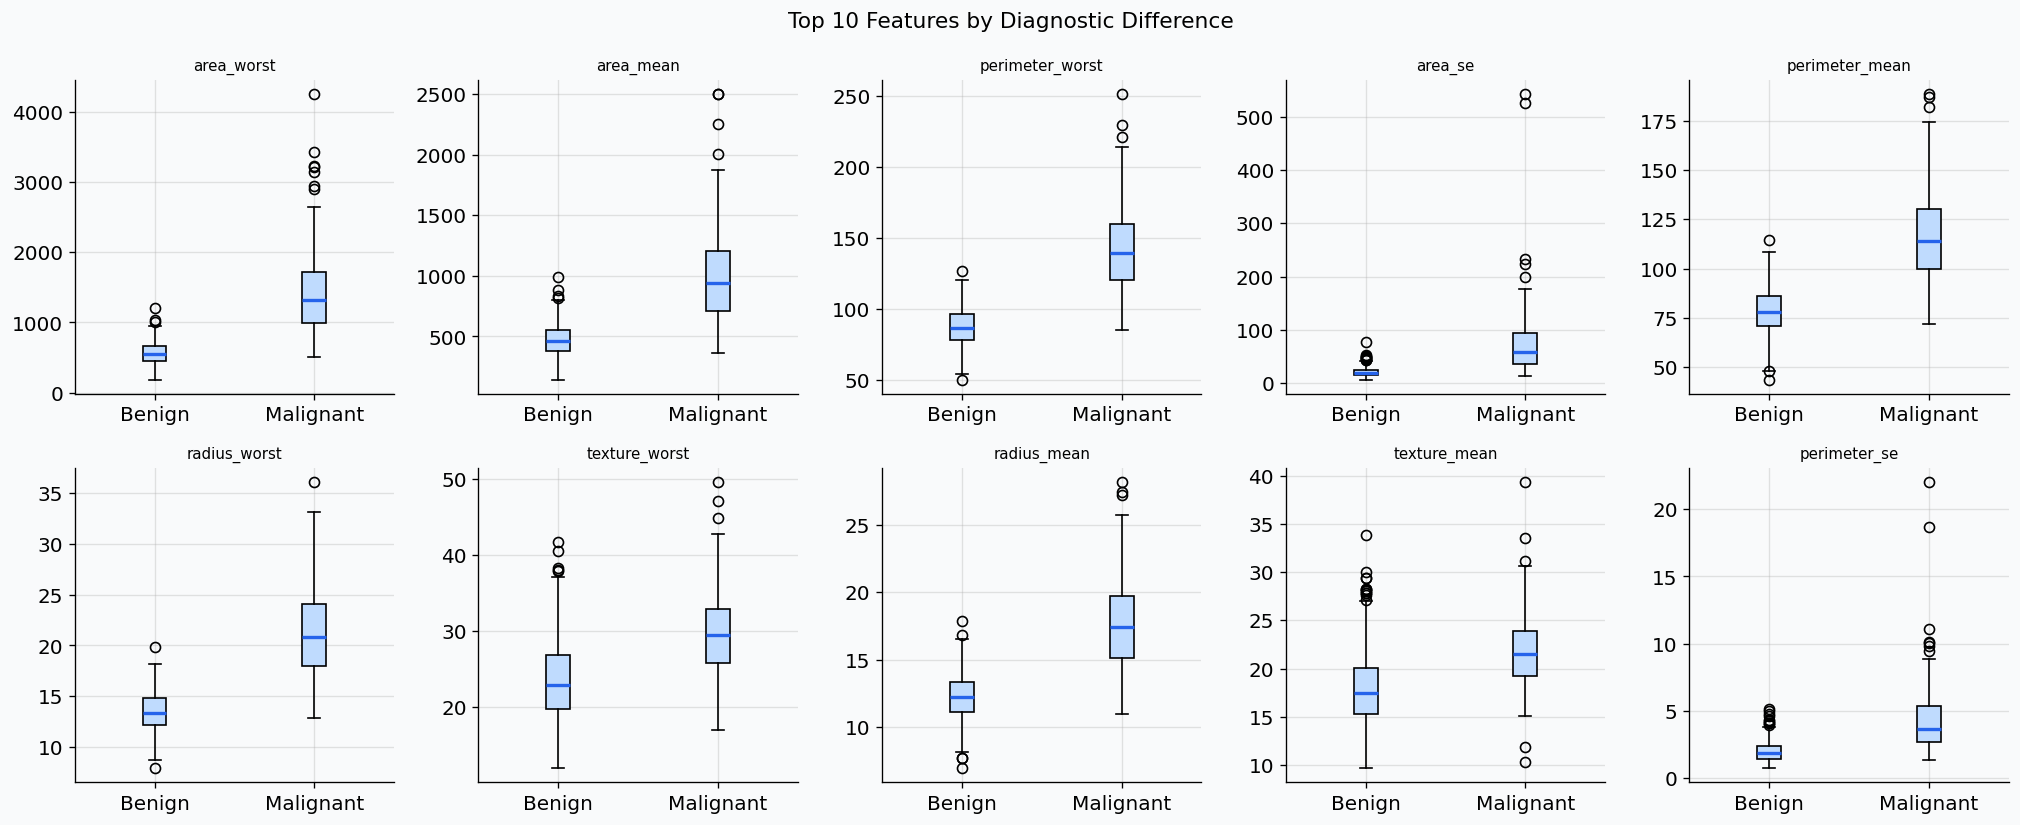

In [7]:
# Box plots of top features split by diagnosis
fig, axes = plt.subplots(2, 5, figsize=(17, 7))
axes = axes.flatten()

for i, feat in enumerate(top10):
    data_b = df_feat.loc[df_feat.label == 0, feat]
    data_m = df_feat.loc[df_feat.label == 1, feat]
    axes[i].boxplot([data_b, data_m], labels=['Benign', 'Malignant'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#BFDBFE'),
                    medianprops=dict(color='#2563EB', linewidth=2))
    axes[i].set_title(feat, fontsize=9)

fig.suptitle('Top 10 Features by Diagnostic Difference', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Train Logistic Regression Pipeline

=== Test Set Performance ===
  Accuracy : 0.9649

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



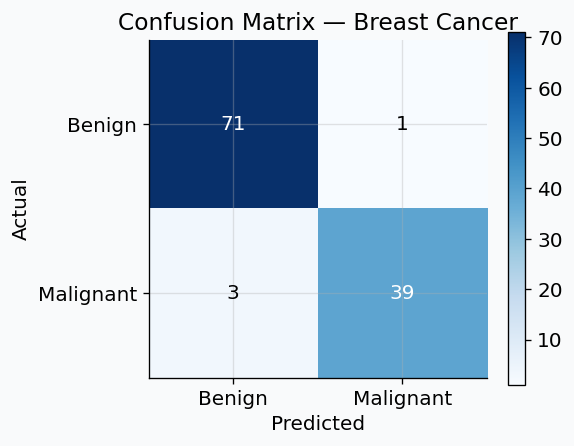

In [8]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('=== Test Set Performance ===')
classification_summary(y_test, y_pred, labels=['Benign', 'Malignant'])

plot_confusion_matrix(y_test, y_pred, labels=['Benign', 'Malignant'],
                      title='Confusion Matrix — Breast Cancer')

## 5. ROC Curve & AUC

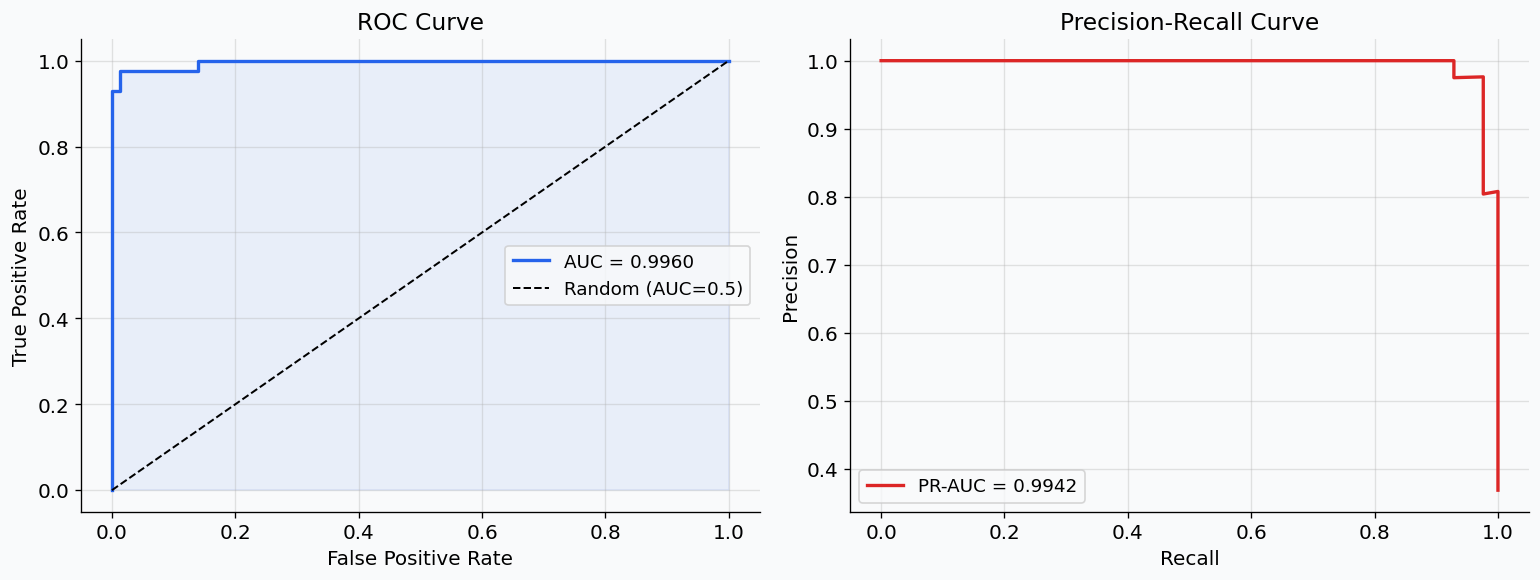

In [9]:
y_proba = pipe.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color='#2563EB', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#2563EB')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
axes[1].plot(recall, precision, color='#DC2626', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Stratified Cross-Validation

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc  = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
cv_roc  = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
cv_f1   = cross_val_score(pipe, X, y, cv=cv, scoring='f1')

print('5-fold Stratified CV:')
print(f'  Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  ROC-AUC  : {cv_roc.mean():.4f} ± {cv_roc.std():.4f}')
print(f'  F1       : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

5-fold Stratified CV:
  Accuracy : 0.9737 ± 0.0166
  ROC-AUC  : 0.9953 ± 0.0053
  F1       : 0.9633 ± 0.0240


## 7. Feature Importance

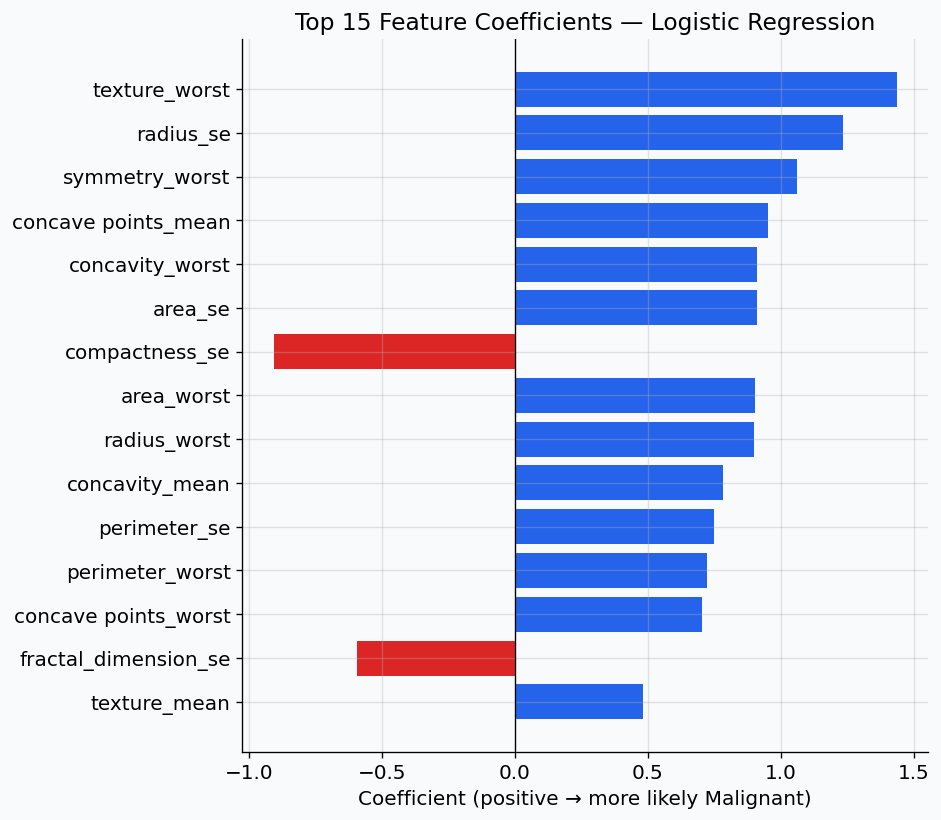

In [11]:
coefs = pipe.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': coefs})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=True).index)
coef_df = coef_df.tail(15)   # top 15

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#DC2626' if v < 0 else '#2563EB' for v in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient (positive → more likely Malignant)')
ax.set_title('Top 15 Feature Coefficients — Logistic Regression')
plt.tight_layout()
plt.show()

## Recap

Applied logistic regression to a real medical classification problem:

1. **Data prep** — encoded binary labels, removed non-numeric columns.
2. **EDA** — box plots revealed which measurements most distinguish malignant from benign.
3. **Pipeline** — `StandardScaler` + `LogisticRegression` for leak-free scaling.
4. **Evaluation** — confusion matrix, ROC/PR curves, stratified CV for unbiased estimates.
5. **Feature importance** — large positive coefficients → strongly associated with malignancy.

**You have now completed the core ML mathematics journey:**
- ✅ NumPy  
- ✅ Matplotlib  
- ✅ Linear Regression (math + scratch + sklearn + Kaggle)  
- ✅ Gradient Descent (batch / mini-batch / SGD)  
- ✅ Logistic Regression (math + scratch + sklearn + Kaggle)